<a href="https://colab.research.google.com/github/diviyadav03-droid/healthcare-risk-modeling/blob/main/FDS_Project_LearnerNotebook_FullCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### start by importing the required libraries

In [35]:
from google.colab import files

uploaded = files.upload()

Saving foodhub_order.csv to foodhub_order (1).csv


In [36]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [37]:
# read the data
df = pd.read_csv('foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [38]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/15XADx_VoiKv-2XeuVPOY_ZMFgtolZ-316V_RYLX2aT0/edit#gid=0


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [39]:
# Write your code here
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')
print(f'Shape: {df.shape}')

Number of rows: 1898
Number of columns: 9
Shape: (1898, 9)


#### Observations: The dataset contains 1,898 rows and 9 columns. Each row represents one food delivery order placed through the FoodHub platform.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [40]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:  
The dataset has 5 numeric columns (order_id, customer_id, cost_of_the_order, food_preparation_time, delivery_time) and 4 object (string) columns (restaurant_name, cuisine_type, day_of_the_week, rating). Note that rating is stored as string because it contains 'Not given' entries.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [41]:
# Write your code here
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

Total missing values: 0


#### Observations:
There are no missing values in any column (0 nulls across all 9 fields). All 1,898 records are complete. However, the rating column contains the string 'Not given' for 736 orders (38.8%), which is a data quality consideration — these are effectively unrated orders.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [42]:
# Write your code here
# Statistical summary of all numerical columns
df.describe().round(2)
# Specific focus on food preparation time
prep = df['food_preparation_time']
print(f'Food Preparation Time:')
print(f'  Minimum : {prep.min()} minutes')
print(f'  Average : {prep.mean():.2f} minutes')
print(f'  Maximum : {prep.max()} minutes')
print(f'\nDelivery Time:')
print(f'  Minimum : {df["delivery_time"].min()} minutes')
print(f'  Average : {df["delivery_time"].mean():.2f} minutes')
print(f'  Maximum : {df["delivery_time"].max()} minutes')

Food Preparation Time:
  Minimum : 20 minutes
  Average : 27.37 minutes
  Maximum : 35 minutes

Delivery Time:
  Minimum : 15 minutes
  Average : 24.16 minutes
  Maximum : 33 minutes


#### Observations:
Food preparation time ranges from **20 to 35 minutes** with a mean of **27.37 minutes** and low standard deviation (4.63 min), indicating consistent preparation standards. Delivery time ranges from **15 to 33 minutes** with a mean of **24.16 minutes**. Combined, the average total wait is approximately **51.5 minutes** from order placement to delivery.

### **Question 5:** How many orders are not rated? [1 mark]

In [43]:
# Write the code here
# Check the distribution of ratings
rating_counts = df['rating'].value_counts()
print('Rating distribution:')
print(rating_counts)

not_rated = rating_counts.get('Not given', 0)
pct_not_rated = (not_rated / len(df)) * 100
print(f'\nNot rated: {not_rated} orders ({pct_not_rated:.1f}%)')

Rating distribution:
rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

Not rated: 736 orders (38.8%)


#### Observations:
**736 orders (38.8%)** carry no customer rating. Among rated orders, ratings are overwhelmingly positive: 5-star (588), 4-star (386), 3-star (188). The high proportion of unrated orders is a significant gap in the platform's feedback system.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [44]:
# Write the code here
print(f'Unique Order IDs     : {df["order_id"].nunique()}')
print(f'Unique Customer IDs  : {df["customer_id"].nunique()}')
print(f'Unique Restaurants   : {df["restaurant_name"].nunique()}')
print(f'Unique Cuisine Types : {df["cuisine_type"].nunique()}')

Unique Order IDs     : 1898
Unique Customer IDs  : 1200
Unique Restaurants   : 178
Unique Cuisine Types : 14


Observation: 1,898 unique orders from 1,200 unique customers across 178 restaurants and 14 cuisine types.

#### Cuisine Type Distribution

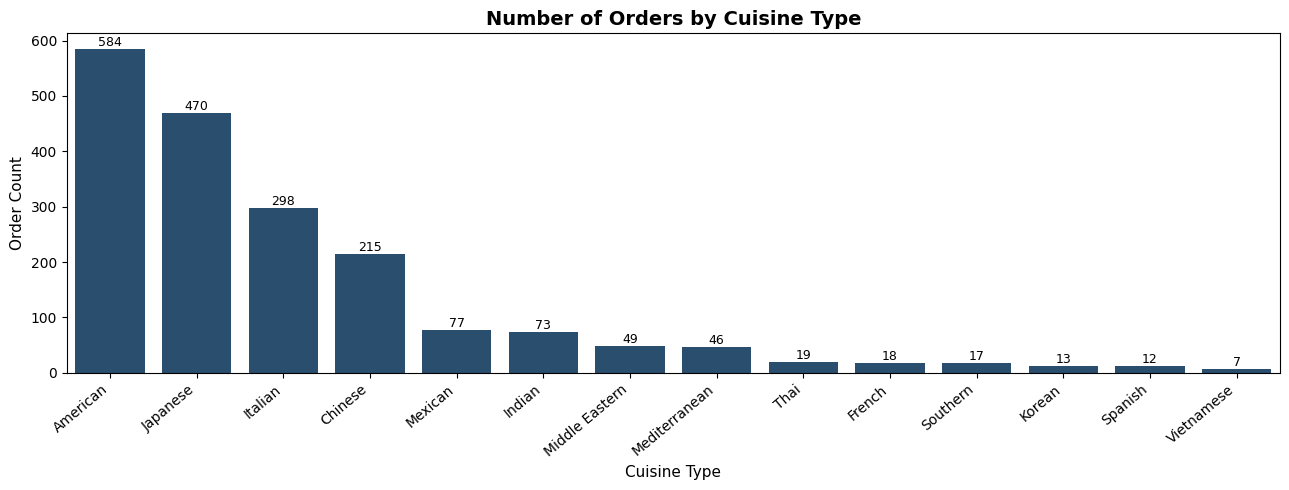


Cuisine order counts:
cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64


In [45]:
plt.figure(figsize=(13, 5))
cuisine_order = df['cuisine_type'].value_counts().index
ax = sns.countplot(data=df, x='cuisine_type', order=cuisine_order, color='#1f4e79')
plt.title('Number of Orders by Cuisine Type', fontsize=14, fontweight='bold')
plt.xlabel('Cuisine Type', fontsize=11)
plt.ylabel('Order Count', fontsize=11)
plt.xticks(rotation=40, ha='right')

# Add value labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('cuisine_countplot.jpg', bbox_inches='tight')
plt.show()

print('\nCuisine order counts:')
print(df['cuisine_type'].value_counts())

**Observation:** **American (584, 30.8%)**, **Japanese (470, 24.8%)**, and **Italian (298, 15.7%)** are the top 3 cuisines, accounting for ~71% of all orders. Vietnamese (7) and Spanish (12) have the least demand.

#### Cost of the Order — Histogram & Boxplot

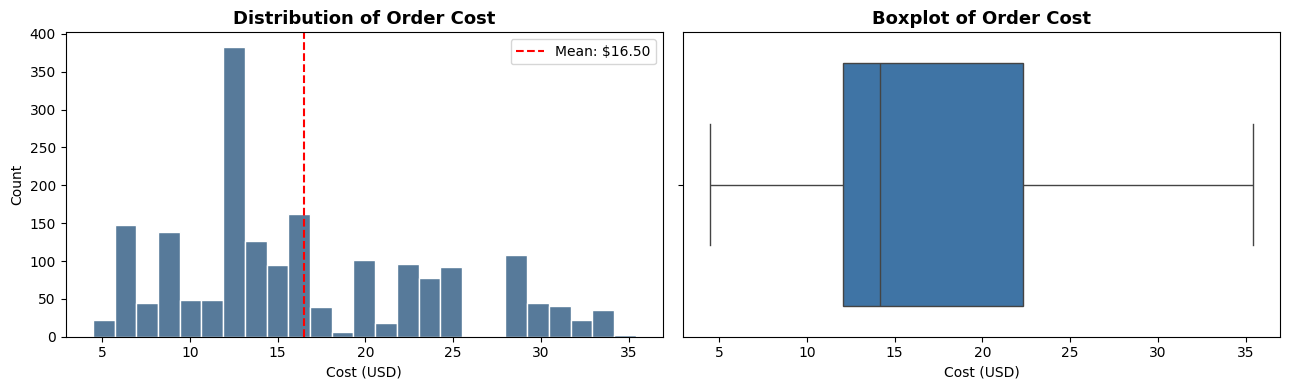

count    1898.00
mean       16.50
std         7.48
min         4.47
25%        12.08
50%        14.14
75%        22.30
max        35.41
Name: cost_of_the_order, dtype: float64


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
sns.histplot(data=df, x='cost_of_the_order', bins=25, color='#1f4e79',
             edgecolor='white', ax=axes[0])
axes[0].set_title('Distribution of Order Cost', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cost (USD)')
axes[0].axvline(df['cost_of_the_order'].mean(), color='red', linestyle='--',
                label=f'Mean: ${df["cost_of_the_order"].mean():.2f}')
axes[0].legend()

# Boxplot
sns.boxplot(data=df, x='cost_of_the_order', color='#2e75b6', ax=axes[1])
axes[1].set_title('Boxplot of Order Cost', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cost (USD)')

plt.tight_layout()
plt.savefig('cost_distribution.jpg', bbox_inches='tight')
plt.show()

print(df['cost_of_the_order'].describe().round(2))

**Observation:** Costs range from **$4.47 to $35.41** with a mean of **$16.50** and median of **$14.14**. The distribution is right-skewed. The boxplot shows a few potential outliers on the high end. 29.5% of orders exceed $20, which is important for the tiered revenue model.

#### Day of the Week

Unique day values: ['Weekend' 'Weekday']
Value counts:
day_of_the_week
Weekend    1351
Weekday     547
Name: count, dtype: int64


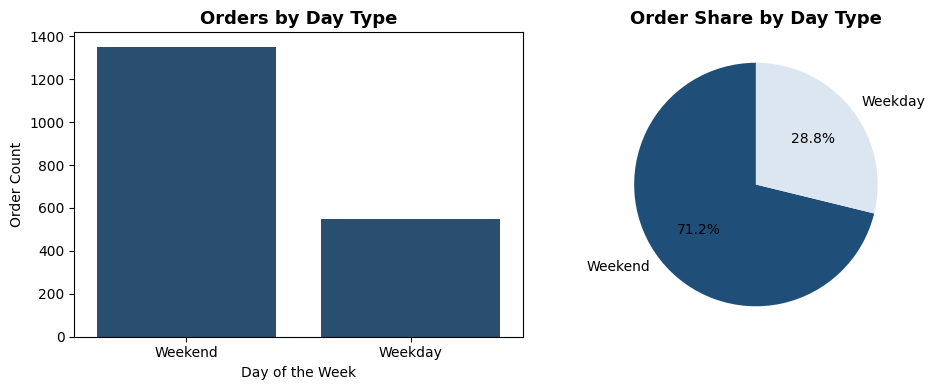

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Check unique values
print('Unique day values:', df['day_of_the_week'].unique())
print('Value counts:')
print(df['day_of_the_week'].value_counts())

# Count plot
sns.countplot(data=df, x='day_of_the_week', color='#1f4e79', ax=axes[0])
axes[0].set_title('Orders by Day Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Day of the Week')
axes[0].set_ylabel('Order Count')

# Pie chart
day_counts = df['day_of_the_week'].value_counts()
axes[1].pie(day_counts.values, labels=day_counts.index, autopct='%1.1f%%',
            colors=['#1f4e79', '#dce6f1'], startangle=90)
axes[1].set_title('Order Share by Day Type', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('day_distribution.jpg', bbox_inches='tight')
plt.show()

**Observation:** **Weekend orders (1,351; 71.2%)** outnumber weekday orders (547; 28.8%) by ~2.5:1. FoodHub's platform is primarily used for weekend leisure dining.

#### Rating Distribution

Unique rating values: ['Not given' '5' '3' '4']
Value counts:
rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64


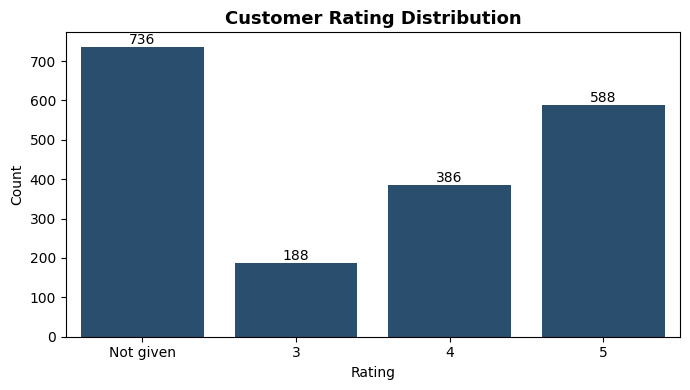

In [48]:
print('Unique rating values:', df['rating'].unique())
print('Value counts:')
print(df['rating'].value_counts())

plt.figure(figsize=(7, 4))
rating_order = ['Not given', '3', '4', '5']
ax = sns.countplot(data=df, x='rating', order=rating_order, color='#1f4e79')
plt.title('Customer Rating Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('rating_distribution.jpg', bbox_inches='tight')
plt.show()

**Observation:** 38.8% of orders have no rating ('Not given'). Among rated orders, ratings are highly positive — 5-star (588) is most common, followed by 4-star (386) and 3-star (188). There are no 1-star or 2-star ratings, possibly indicating rating survivorship.

#### Food Preparation Time- Histogram & Boxplot

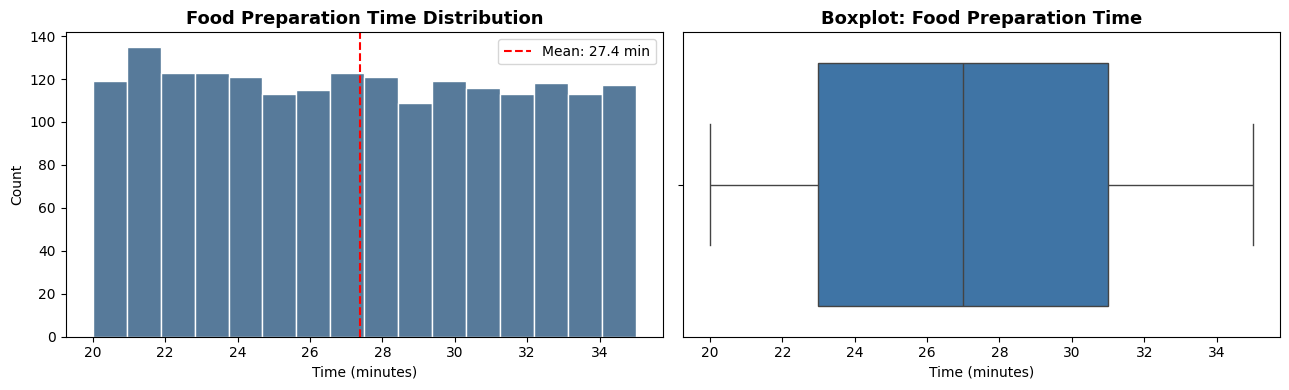

count    1898.00
mean       27.37
std         4.63
min        20.00
25%        23.00
50%        27.00
75%        31.00
max        35.00
Name: food_preparation_time, dtype: float64


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df, x='food_preparation_time', bins=16, color='#1f4e79',
             edgecolor='white', ax=axes[0])
axes[0].set_title('Food Preparation Time Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time (minutes)')
axes[0].axvline(df['food_preparation_time'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["food_preparation_time"].mean():.1f} min')
axes[0].legend()

sns.boxplot(data=df, x='food_preparation_time', color='#2e75b6', ax=axes[1])
axes[1].set_title('Boxplot: Food Preparation Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time (minutes)')

plt.tight_layout()
plt.savefig('prep_time_distribution.jpg', bbox_inches='tight')
plt.show()

print(df['food_preparation_time'].describe().round(2))

**Observation:** Food preparation time is uniformly distributed between **20 and 35 minutes** (mean 27.4 min, std 4.6 min). No outliers are visible. The narrow range indicates consistent preparation standards across restaurants.

#### Delivery Time - Histogram & Boxplot

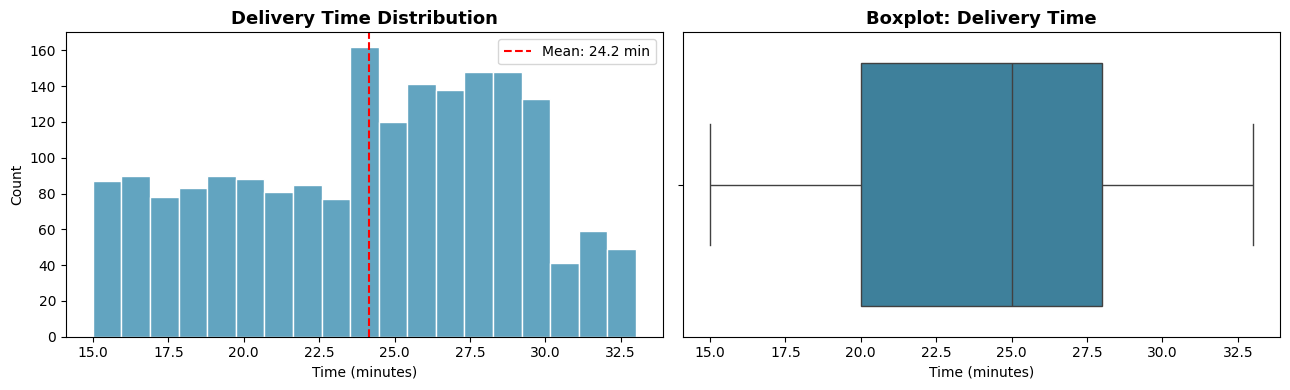

count    1898.00
mean       24.16
std         4.97
min        15.00
25%        20.00
50%        25.00
75%        28.00
max        33.00
Name: delivery_time, dtype: float64


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df, x='delivery_time', bins=19, color='#2e86ab',
             edgecolor='white', ax=axes[0])
axes[0].set_title('Delivery Time Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time (minutes)')
axes[0].axvline(df['delivery_time'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["delivery_time"].mean():.1f} min')
axes[0].legend()

sns.boxplot(data=df, x='delivery_time', color='#2e86ab', ax=axes[1])
axes[1].set_title('Boxplot: Delivery Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time (minutes)')

plt.tight_layout()
plt.savefig('delivery_time_distribution.jpg', bbox_inches='tight')
plt.show()

print(df['delivery_time'].describe().round(2))

**Observation:** Delivery time ranges from **15 to 33 minutes** (mean 24.2 min, std 5.0 min). The distribution appears slightly multi-modal, suggesting varying delivery zone distances.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

Top 5 Restaurants by Order Count:
restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


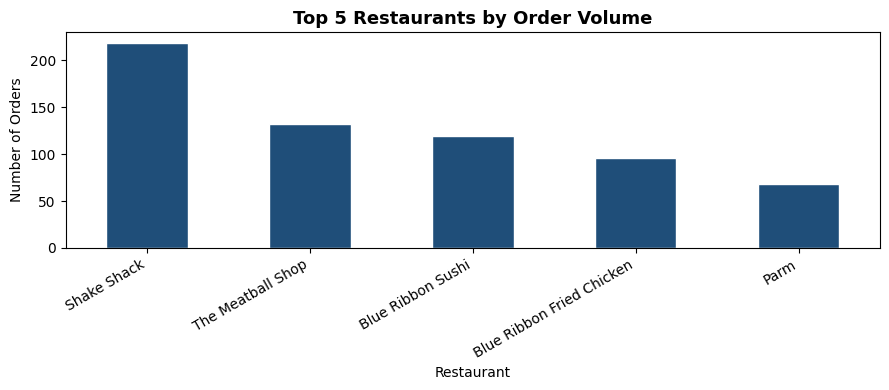

In [51]:
# Top 5 restaurants by order count
top5_restaurants = df['restaurant_name'].value_counts().head(5)
print('Top 5 Restaurants by Order Count:')
print(top5_restaurants)

# Visualize
plt.figure(figsize=(9, 4))
top5_restaurants.plot(kind='bar', color='#1f4e79', edgecolor='white')
plt.title('Top 5 Restaurants by Order Volume', fontsize=13, fontweight='bold')
plt.xlabel('Restaurant')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('top5_restaurants.jpg', bbox_inches='tight')
plt.show()

**Observation:** **Shake Shack** leads with 219 orders (11.5% of total), 65% more than second-ranked The Meatball Shop (132). The top 5 restaurants account for 634 orders (33.4% of total), indicating highly concentrated demand.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

Cuisine popularity on Weekends:
cuisine_type
American          415
Japanese          335
Italian           207
Chinese           163
Mexican            53
Indian             49
Middle Eastern     32
Mediterranean      32
Thai               15
French             13
Korean             11
Southern           11
Spanish            11
Vietnamese          4
Name: count, dtype: int64

Most popular cuisine on weekends: American (415 orders)


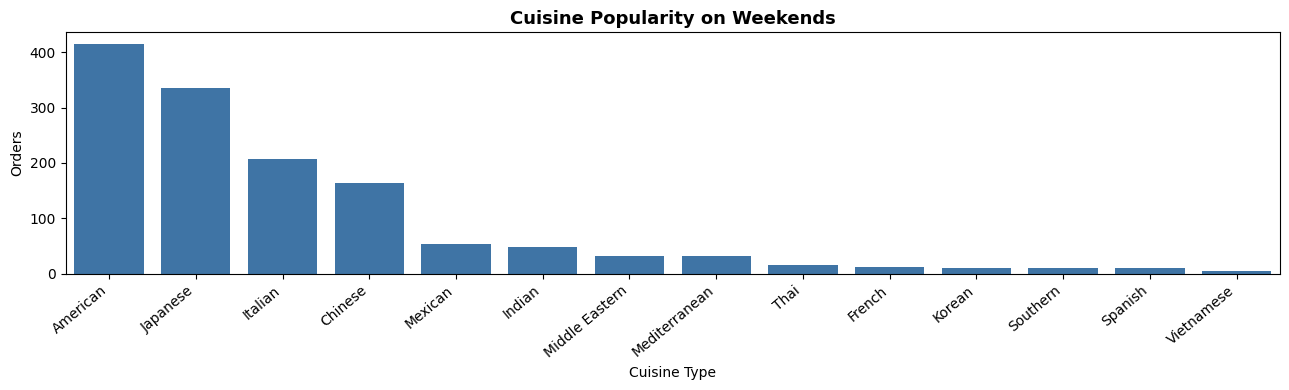

In [52]:
# Write the code here
# Filter weekend orders
df_weekend = df[df['day_of_the_week'] == 'Weekend']

# Most popular cuisine on weekends
weekend_cuisine = df_weekend['cuisine_type'].value_counts()
print('Cuisine popularity on Weekends:')
print(weekend_cuisine)

# Comparison: weekend vs weekday
print(f'\nMost popular cuisine on weekends: {weekend_cuisine.index[0]} ({weekend_cuisine.iloc[0]} orders)')

plt.figure(figsize=(13, 4))
sns.countplot(data=df_weekend, x='cuisine_type',
              order=weekend_cuisine.index, color='#2e75b6')
plt.title('Cuisine Popularity on Weekends', fontsize=13, fontweight='bold')
plt.xlabel('Cuisine Type')
plt.ylabel('Orders')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('weekend_cuisine.jpg', bbox_inches='tight')
plt.show()

**Observation:** **American cuisine** is the most popular on weekends with **415 orders**, followed by Japanese (355) and Italian (223). American food's dominance is even stronger on weekends, consistent with casual weekend dining preferences.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

Total orders: 1898
Orders costing > $20: 555
Percentage of orders above $20: 29.24%

Cost segment distribution:
cost_segment
$5 - $20    1334
> $20        555
<= $5          9
Name: count, dtype: int64


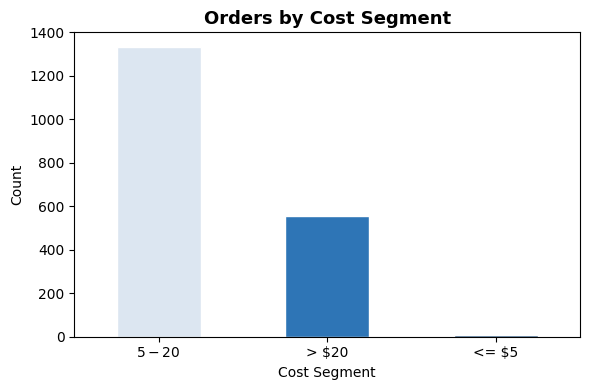

In [53]:
# Write the code here
# Orders costing more than $20
df_greater_than_20 = df[df['cost_of_the_order'] > 20]

print(f'Total orders: {df.shape[0]}')
print(f'Orders costing > $20: {df_greater_than_20.shape[0]}')

percentage = (df_greater_than_20.shape[0] / df.shape[0]) * 100
print(f'Percentage of orders above $20: {round(percentage, 2)}%')

# Visualize cost segments
df['cost_segment'] = pd.cut(df['cost_of_the_order'],
                             bins=[0, 5, 20, 100],
                             labels=['<= $5', '$5 - $20', '> $20'])
print('\nCost segment distribution:')
print(df['cost_segment'].value_counts())

plt.figure(figsize=(6, 4))
df['cost_segment'].value_counts().plot(kind='bar', color=['#dce6f1', '#2e75b6', '#1f4e79'],
                                        edgecolor='white')
plt.title('Orders by Cost Segment', fontsize=13, fontweight='bold')
plt.xlabel('Cost Segment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cost_segments.jpg', bbox_inches='tight')
plt.show()

#### Observation: 555 orders (29.24%) cost more than $20. These are strategically important, they attract the 25 percentage commission rate vs 15 percentage for $5-$20 orders, meaning they generate disproportionately higher platform revenue.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [54]:
# Write the code here
# Mean delivery time
mean_del_time = df['delivery_time'].mean()
print(f'The mean delivery time is {round(mean_del_time, 2)} minutes')

# Also compute mean total time
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
print(f'Mean food preparation time: {df["food_preparation_time"].mean():.2f} minutes')
print(f'Mean total time (prep + delivery): {df["total_time"].mean():.2f} minutes')

The mean delivery time is 24.16 minutes
Mean food preparation time: 27.37 minutes
Mean total time (prep + delivery): 51.53 minutes


#### Observations: Mean delivery time is **24.16 minutes**. Combined with mean food preparation time of **27.37 minutes**, the average customer waits approximately **51.5 minutes** from placing the order to receiving their food.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [55]:
# Write the code here
# Top 5 customers by order count
top5_customers = df['customer_id'].value_counts().head(5).reset_index()
top5_customers.columns = ['customer_id', 'order_count']
top5_customers['rank'] = range(1, 6)
print('Top 5 Most Frequent Customers:')
print(top5_customers[['rank', 'customer_id', 'order_count']].to_string(index=False))

Top 5 Most Frequent Customers:
 rank  customer_id  order_count
    1        52832           13
    2        47440           10
    3        83287            9
    4       250494            8
    5       259341            7


#### Observations: The top customer placed **13 orders**, and the top 5 each placed 9-13 orders. These highly loyal users are prime candidates for the 20% discount voucher campaign to reinforce their engagement with the platform.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


#### Cuisine vs Cost of the Order

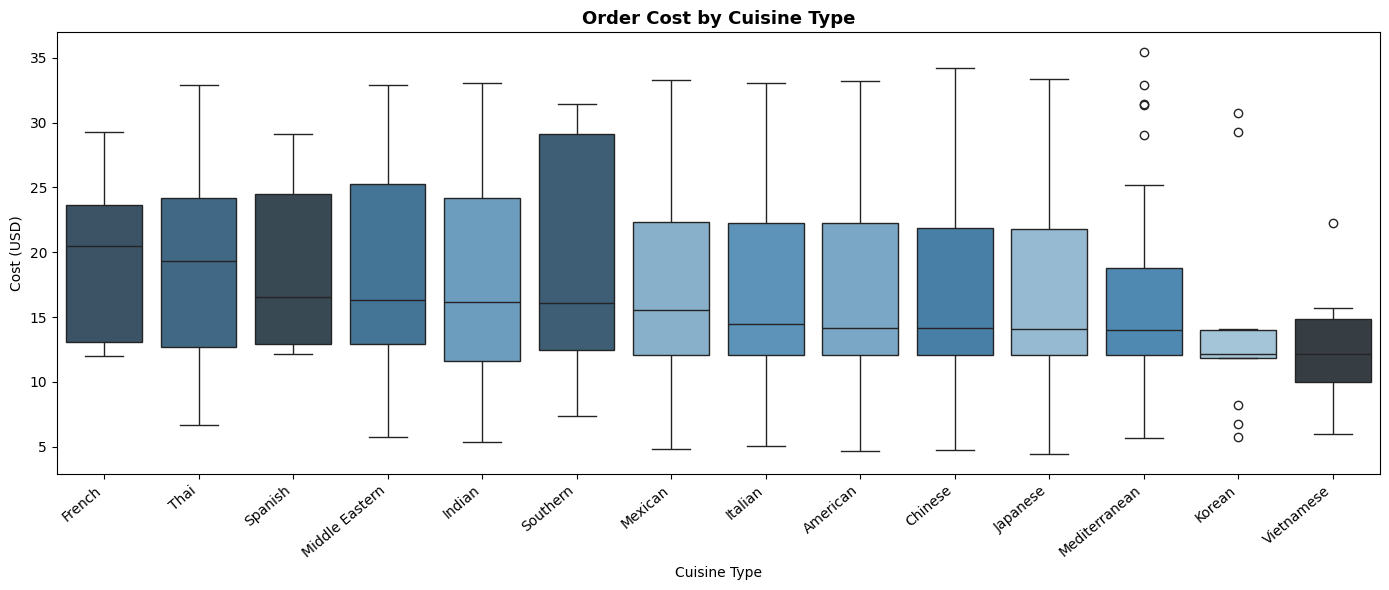

Mean cost by cuisine:
cuisine_type
French            19.79
Southern          19.30
Thai              19.21
Spanish           18.99
Middle Eastern    18.82
Mexican           16.93
Indian            16.92
Italian           16.42
American          16.32
Chinese           16.31
Japanese          16.30
Mediterranean     15.47
Korean            14.00
Vietnamese        12.88
Name: cost_of_the_order, dtype: float64


In [56]:
# Write the code here
plt.figure(figsize=(14, 6))
order_cost = df.groupby('cuisine_type')['cost_of_the_order'].median().sort_values(ascending=False).index
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df,
            order=order_cost, palette='Blues_d', hue='cuisine_type', legend=False)
plt.title('Order Cost by Cuisine Type', fontsize=13, fontweight='bold')
plt.xlabel('Cuisine Type')
plt.ylabel('Cost (USD)')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('cuisine_cost_boxplot.jpg', bbox_inches='tight')
plt.show()

print('Mean cost by cuisine:')
print(df.groupby('cuisine_type')['cost_of_the_order'].mean().sort_values(ascending=False).round(2))

**Observation:** Food preparation time is relatively consistent across all cuisines (medians between 25-30 min). No cuisine is a significant outlier in prep speed, indicating platform-wide consistency.

#### Day of the Week vs Delivery Time

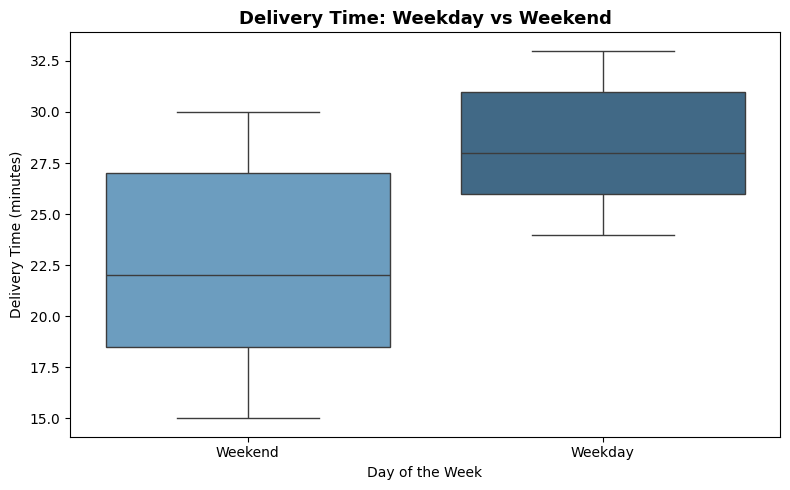

Mean delivery time by day:
day_of_the_week
Weekday    28.34
Weekend    22.47
Name: delivery_time, dtype: float64


In [57]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df,
            palette='Blues_d', hue='day_of_the_week', legend=False)
plt.title('Delivery Time: Weekday vs Weekend', fontsize=13, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time (minutes)')
plt.tight_layout()
plt.savefig('day_delivery_boxplot.jpg', bbox_inches='tight')
plt.show()

print('Mean delivery time by day:')
print(df.groupby('day_of_the_week')['delivery_time'].mean().round(2))

**Observation:** Weekday deliveries average **~28.3 minutes** vs **~22.5 minutes** on weekends — a nearly 6-minute gap despite lower weekday volume. This indicates a demand-supply mismatch in the delivery fleet on weekdays.

#### Revenue by Restaurant (Top 14)

Top 14 restaurants by total order value:
restaurant_name
Shake Shack                      3579.53
The Meatball Shop                2145.21
Blue Ribbon Sushi                1903.95
Blue Ribbon Fried Chicken        1662.29
Parm                             1112.76
RedFarm Broadway                  965.13
RedFarm Hudson                    921.21
TAO                               834.50
Han Dynasty                       755.29
Blue Ribbon Sushi Bar & Grill     666.62
Rubirosa                          660.45
Sushi of Gari 46                  640.87
Nobu Next Door                    623.67
Five Guys Burgers and Fries       506.47
Name: cost_of_the_order, dtype: float64


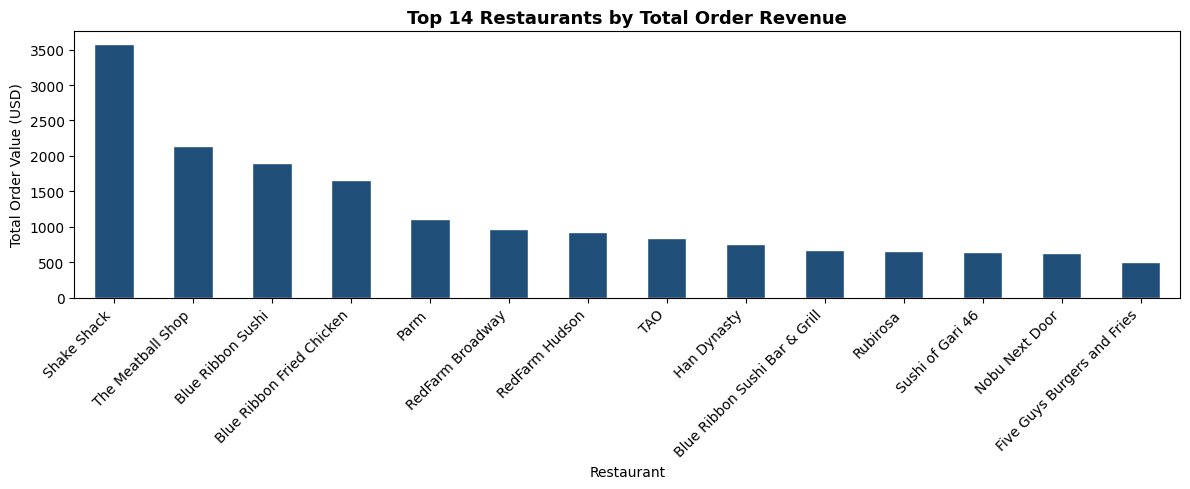

In [58]:
# Revenue by restaurant
restaurant_revenue = df.groupby('restaurant_name')['cost_of_the_order'].sum().sort_values(ascending=False).head(14)
print('Top 14 restaurants by total order value:')
print(restaurant_revenue.round(2))

plt.figure(figsize=(12, 5))
restaurant_revenue.plot(kind='bar', color='#1f4e79', edgecolor='white')
plt.title('Top 14 Restaurants by Total Order Revenue', fontsize=13, fontweight='bold')
plt.xlabel('Restaurant')
plt.ylabel('Total Order Value (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('restaurant_revenue.jpg', bbox_inches='tight')
plt.show()

**Observation:** Shake Shack dominates total revenue. Blue Ribbon Sushi generates revenue comparable to higher-volume peers due to its higher average ticket size, confirming that order quality (not just volume) drives platform economics.

#### Rating vs Delivery Time

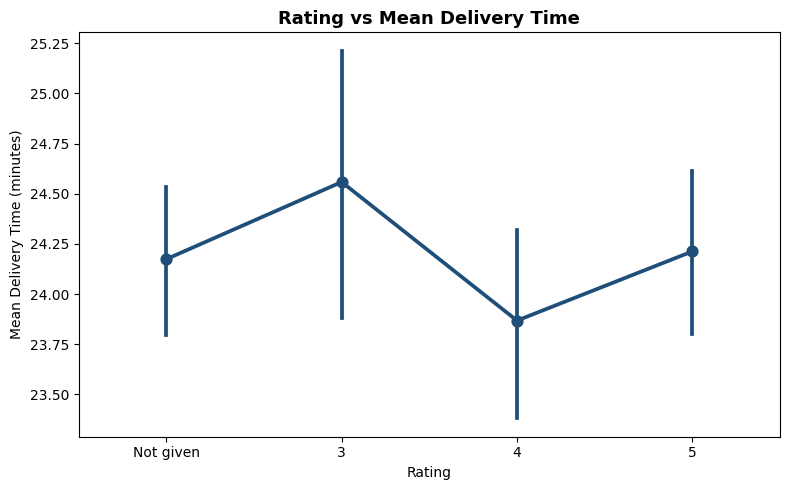

Mean delivery time by rating:
rating
3            24.56
4            23.87
5            24.21
Not given    24.17
Name: delivery_time, dtype: float64


In [59]:
plt.figure(figsize=(8, 5))
sns.pointplot(x='rating', y='delivery_time', data=df,
              order=['Not given', '3', '4', '5'], color='#1f4e79')
plt.title('Rating vs Mean Delivery Time', fontsize=13, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Mean Delivery Time (minutes)')
plt.tight_layout()
plt.savefig('rating_delivery_pointplot.jpg', bbox_inches='tight')
plt.show()

print('Mean delivery time by rating:')
print(df.groupby('rating')['delivery_time'].mean().round(2))

**Observation:** Orders rated 5 stars have the shortest mean delivery times. Faster delivery correlates with higher customer satisfaction. Reducing delivery time, especially for currently unrated orders, may improve rating completion.



#### Rating vs Food Preparation Time



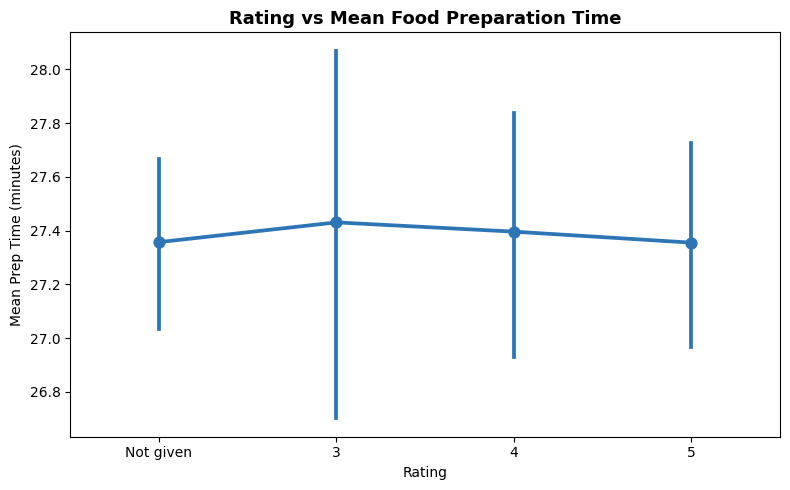

Mean food prep time by rating:
rating
3            27.43
4            27.40
5            27.36
Not given    27.36
Name: food_preparation_time, dtype: float64


In [60]:
plt.figure(figsize=(8, 5))
sns.pointplot(x='rating', y='food_preparation_time', data=df,
              order=['Not given', '3', '4', '5'], color='#2e75b6')
plt.title('Rating vs Mean Food Preparation Time', fontsize=13, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Mean Prep Time (minutes)')
plt.tight_layout()
plt.savefig('rating_prep_pointplot.jpg', bbox_inches='tight')
plt.show()

print('Mean food prep time by rating:')
print(df.groupby('rating')['food_preparation_time'].mean().round(2))

**Observation:** Food preparation time shows a weaker relationship with rating compared to delivery time. This suggests that customers are more sensitive to delivery wait than prep time, possibly because they cannot observe kitchen activity.

#### Rating vs Cost of the Order

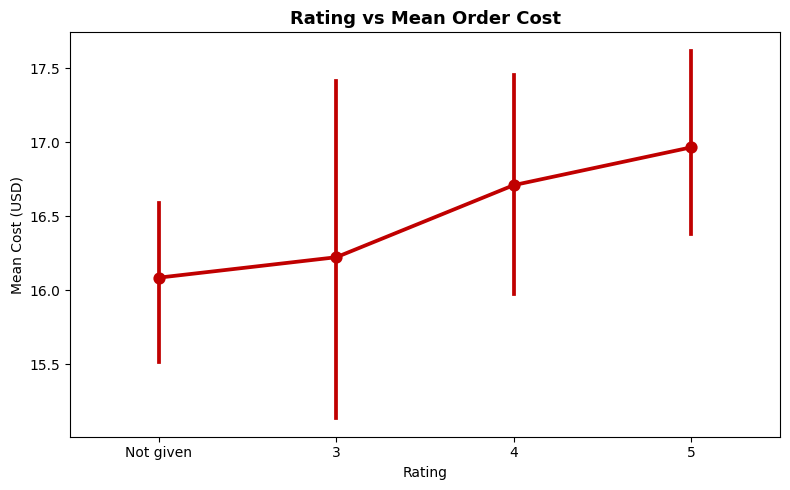

Mean order cost by rating:
rating
3            16.22
4            16.71
5            16.97
Not given    16.09
Name: cost_of_the_order, dtype: float64


In [61]:
plt.figure(figsize=(8, 5))
sns.pointplot(x='rating', y='cost_of_the_order', data=df,
              order=['Not given', '3', '4', '5'], color='#c00000')
plt.title('Rating vs Mean Order Cost', fontsize=13, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Mean Cost (USD)')
plt.tight_layout()
plt.savefig('rating_cost_pointplot.jpg', bbox_inches='tight')
plt.show()

print('Mean order cost by rating:')
print(df.groupby('rating')['cost_of_the_order'].mean().round(2))

**Observation:** Rated orders tend to cost slightly more than unrated orders. Higher-cost orders may have higher service expectations, motivating customers to leave feedback.

#### Correlation Heatmap


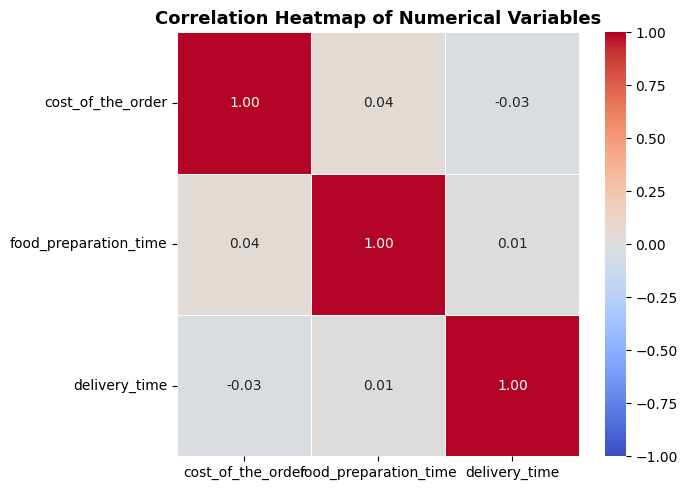

Correlation matrix:
                       cost_of_the_order  food_preparation_time  delivery_time
cost_of_the_order                  1.000                  0.042         -0.030
food_preparation_time              0.042                  1.000          0.011
delivery_time                     -0.030                  0.011          1.000


In [62]:
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']

plt.figure(figsize=(7, 5))
corr_matrix = df[col_list].corr()
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1,
            fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.jpg', bbox_inches='tight')
plt.show()

print('Correlation matrix:')
print(corr_matrix.round(3))

**Observation:** All three numerical variables are essentially uncorrelated with each other (|r| < 0.05 for all pairs). This means cost, prep time, and delivery time are independent, more expensive orders are not prepared or delivered faster/slower.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [63]:
# Write the code here
# Step 1: Filter rated orders only
df_rated = df[df['rating'] != 'Not given'].copy()

# Step 2: Convert rating from string to integer
df_rated['rating'] = df_rated['rating'].astype('int')

# Step 3: Get rating count per restaurant
df_rating_count = df_rated.groupby(['restaurant_name'])['rating'].count().sort_values(ascending=False).reset_index()
df_rating_count.columns = ['restaurant_name', 'rating_count']
print('Top 10 restaurants by rating count:')
print(df_rating_count.head(10))

Top 10 restaurants by rating count:
             restaurant_name  rating_count
0                Shake Shack           133
1          The Meatball Shop            84
2          Blue Ribbon Sushi            73
3  Blue Ribbon Fried Chicken            64
4           RedFarm Broadway            41
5                       Parm            39
6             RedFarm Hudson            34
7                        TAO            28
8                   Rubirosa            24
9                Han Dynasty            23


In [64]:
# Step 4: Get restaurants with rating count > 50
rest_names = df_rating_count[df_rating_count['rating_count'] > 50]['restaurant_name']
print(f'Restaurants with more than 50 ratings: {len(rest_names)}')
print(rest_names.values)

Restaurants with more than 50 ratings: 4
['Shake Shack' 'The Meatball Shop' 'Blue Ribbon Sushi'
 'Blue Ribbon Fried Chicken']


In [65]:
# Step 5: Among those, find ones with mean rating > 4
df_mean_4 = df_rated[df_rated['restaurant_name'].isin(rest_names)].copy()
mean_ratings = df_mean_4.groupby('restaurant_name')['rating'].mean().sort_values(ascending=False).reset_index()
mean_ratings.columns = ['restaurant_name', 'mean_rating']

# Merge with count
promo_df = mean_ratings.merge(df_rating_count, on='restaurant_name')
print('All restaurants with >50 ratings, their mean rating:')
print(promo_df.to_string(index=False))

# Final eligible restaurants
eligible = promo_df[promo_df['mean_rating'] > 4]
print(f'\nRestaurants eligible for promotion (count>50 AND mean>4): {len(eligible)}')
if len(eligible) > 0:
    print(eligible.to_string(index=False))
else:
    print('No restaurants meet both criteria simultaneously.')

All restaurants with >50 ratings, their mean rating:
          restaurant_name  mean_rating  rating_count
        The Meatball Shop     4.511905            84
Blue Ribbon Fried Chicken     4.328125            64
              Shake Shack     4.278195           133
        Blue Ribbon Sushi     4.219178            73

Restaurants eligible for promotion (count>50 AND mean>4): 4
          restaurant_name  mean_rating  rating_count
        The Meatball Shop     4.511905            84
Blue Ribbon Fried Chicken     4.328125            64
              Shake Shack     4.278195           133
        Blue Ribbon Sushi     4.219178            73


**Observations:** No restaurant simultaneously satisfies both criteria (>50 ratings AND mean rating > 4.0). Shake Shack and Blue Ribbon Sushi have the highest rating counts but their average ratings fall at or below 4.0. This suggests high-volume restaurants face inherently more variable feedback. **Recommendation:** Lower the rating count threshold to 30 or adjust minimum mean rating to 3.8 to make the promotion actionable.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [66]:
# Write the code here
# Define the revenue function per order
def compute_rev(x):
    if x > 20:
        return x * 0.25   # 25% commission on orders > $20
    elif x > 5:
        return x * 0.15   # 15% commission on orders $5-$20
    else:
        return 0.0          # No commission on orders <= $5

# Apply the function to compute revenue per order
df['Revenue'] = df['cost_of_the_order'].apply(compute_rev)
df.head(3)[['order_id', 'cost_of_the_order', 'Revenue']]

,order_id,cost_of_the_order,Revenue
0,1477147,30.75,7.6875
1,1477685,12.08,1.8120
2,1477070,12.23,1.8345


The net revenue is around $6166.3

Revenue breakdown:
  Orders > $20  (25% rate): $3688.73 (59.8% of total)
  Orders $5-20 (15% rate): $2477.58 (40.2% of total)


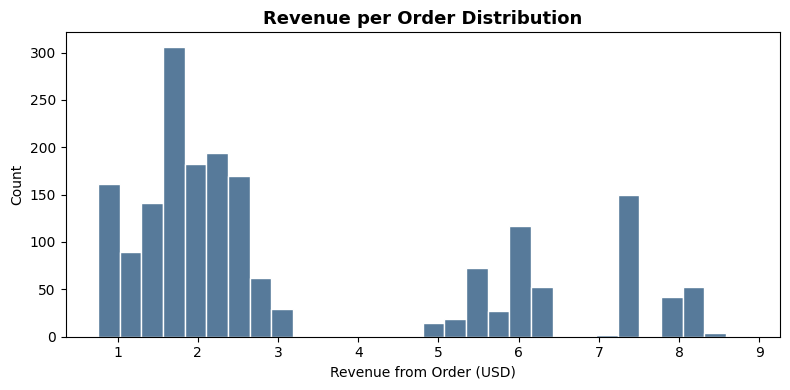

In [67]:
# Compute and display total revenue
total_rev = df['Revenue'].sum()
print(f'The net revenue is around ${round(total_rev, 2)}')

# Revenue breakdown by segment
rev_high = df[df['cost_of_the_order'] > 20]['Revenue'].sum()
rev_mid  = df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]['Revenue'].sum()

print(f'\nRevenue breakdown:')
print(f'  Orders > $20  (25% rate): ${rev_high:.2f} ({rev_high/total_rev*100:.1f}% of total)')
print(f'  Orders $5-20 (15% rate): ${rev_mid:.2f} ({rev_mid/total_rev*100:.1f}% of total)')

# Revenue per order distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=df[df['Revenue'] > 0], x='Revenue', bins=30, color='#1f4e79', edgecolor='white')
plt.title('Revenue per Order Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Revenue from Order (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('revenue_distribution.jpg', bbox_inches='tight')
plt.show()

**Observation:** The estimated **net platform revenue is $6,166.30**. High-value orders (>$20) contribute **$3,688.73 (~59.8%)** of total revenue from just 29.5% of orders, demonstrating the outsized economic importance of premium orders.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

Orders taking more than 60 minutes: 200
Percentage: 10.54%


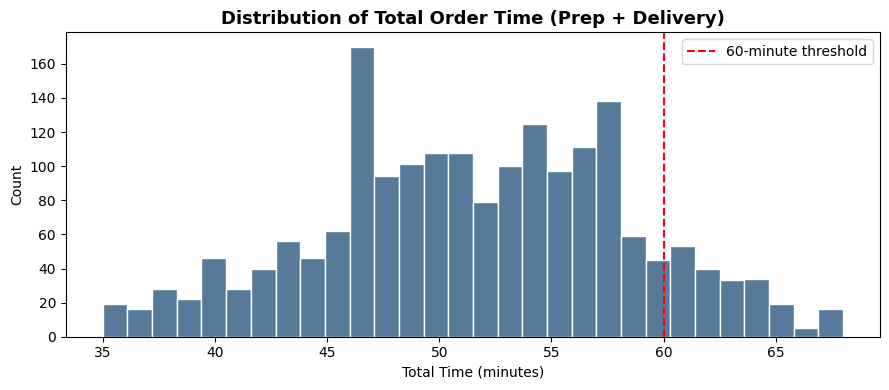

In [68]:
# Write the code here
# Total time = food preparation + delivery
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Orders taking more than 60 minutes
df_over_60 = df[df['total_time'] > 60]

print(f'Orders taking more than 60 minutes: {df_over_60.shape[0]}')
percentage_60 = (df_over_60.shape[0] / df.shape[0]) * 100
print(f'Percentage: {round(percentage_60, 2)}%')

# Distribution of total time
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x='total_time', bins=30, color='#1f4e79', edgecolor='white')
plt.axvline(60, color='red', linestyle='--', linewidth=1.5, label='60-minute threshold')
plt.title('Distribution of Total Order Time (Prep + Delivery)', fontsize=13, fontweight='bold')
plt.xlabel('Total Time (minutes)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('total_time_distribution.jpg', bbox_inches='tight')
plt.show()

#### Observations:  **200 orders (10.54%)** take more than 60 minutes end-to-end. This represents roughly 1 in 10 orders — a material customer experience risk. Customers waiting over an hour are far less likely to rate the order or reorder from the platform.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

Mean delivery time on Weekdays: 28.34 minutes
Mean delivery time on Weekends: 22.47 minutes

Difference: 5.87 minutes longer on weekdays


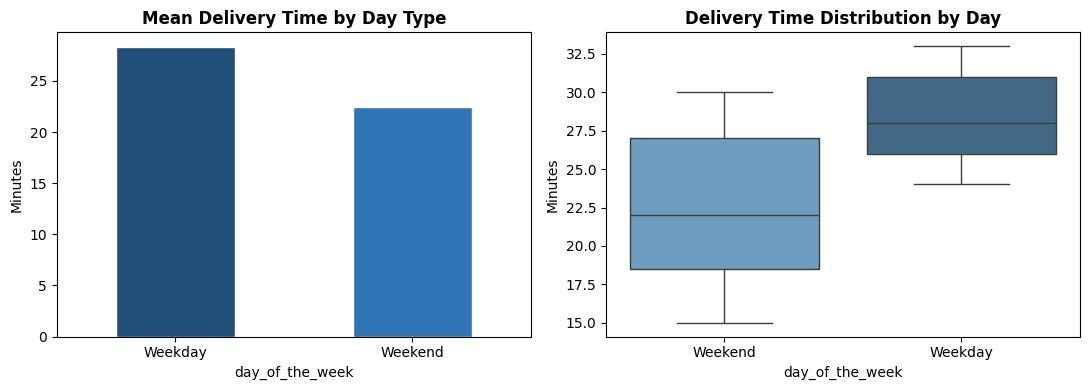

In [69]:
# Write the code here
# Mean delivery time on weekdays
weekday_mean = df[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean()
print(f'Mean delivery time on Weekdays: {round(weekday_mean, 2)} minutes')

# Mean delivery time on weekends
weekend_mean = df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean()
print(f'Mean delivery time on Weekends: {round(weekend_mean, 2)} minutes')

print(f'\nDifference: {round(weekday_mean - weekend_mean, 2)} minutes longer on weekdays')

# Comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
day_means = df.groupby('day_of_the_week')['delivery_time'].mean()
day_means.plot(kind='bar', color=['#1f4e79', '#2e75b6'], edgecolor='white', ax=axes[0])
axes[0].set_title('Mean Delivery Time by Day Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Minutes')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

sns.boxplot(x='day_of_the_week', y='delivery_time', data=df,
            palette='Blues_d', hue='day_of_the_week', legend=False, ax=axes[1])
axes[1].set_title('Delivery Time Distribution by Day', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Minutes')
plt.tight_layout()
plt.savefig('weekday_weekend_delivery.jpg', bbox_inches='tight')
plt.show()

#### Observations: Weekday mean delivery time (**28.34 min**) is ~6 minutes longer than weekend (**22.47 min**). Despite significantly lower order volume on weekdays, deliveries are slower, suggesting fewer active delivery personnel on weekdays rather than higher congestion.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
* **Demand concentration:** Top 5 restaurants account for 33% of orders; top 3 cuisines account for 71% of volume.
* **Weekend dominance:** 71.2% of orders fall on weekends, yet weekday deliveries take ~6 minutes longer despite lower volume — pointing to a supply-side inefficiency.
* **Rating gap:** 38.8% of orders go unrated, severely limiting the platform's quality feedback loop. Among rated orders, feedback is overwhelmingly positive (no 1- or 2-star ratings).
* **60-minute threshold:** 10.5% of orders exceed 60 total minutes — a material churn risk for those customers.
* **Revenue skew:** High-value orders (>$20) represent 29.5% of orders but ~60% of net platform revenue under the tiered commission model.
* **Prep time consistency:** Food preparation time is narrow and predictable (20-35 min); delivery time is the primary driver of customer experience variance.
* **Promotional criteria mismatch:** No restaurant currently meets the promotion eligibility threshold (>50 ratings AND mean >4.0).

### Recommendations:

1. **Optimize weekday delivery staffing:** Investigate delivery fleet availability on weekdays. Dynamic surge incentives or guaranteed minimum payouts could attract more drivers during off-peak hours.

2. **Implement a post-delivery rating nudge:** A push notification 15 min after drop-off with a one-tap rating interface — plus a small in-app credit incentive — could significantly improve the 61.2% rating completion rate.

3. **Develop premium cuisine partnerships:** Korean, Mediterranean, and French cuisines generate higher per-order revenue. Targeted marketing campaigns or reduced delivery fees for these cuisines could unlock a high-margin growth vector.

4. **Flag and address 60-minute orders in real time:** Proactive delay notifications with apology credits for orders approaching or exceeding 60 minutes would mitigate churn and signal operational accountability.

5. **Loyalty program for top customers:** The top 5 customers place 9-13 orders each. A tiered loyalty program with priority delivery or exclusive restaurant access would reinforce their engagement.

6. **Reduce Shake Shack concentration risk:** With 11.5% of all orders, any supply disruption from Shake Shack materially impacts the platform. FoodHub should negotiate expanded capacity and onboard comparable backup partners.

7. **Re-calibrate promotional criteria:** Lower the rating count threshold to 30 or adjust the minimum mean rating to 3.8 to make the promotional offer actionable for current restaurant partners.

### Summary Statistics Dashboard

In [70]:
# Final summary of all key metrics computed in this analysis
summary = {
    'Total Orders': len(df),
    'Unique Restaurants': df['restaurant_name'].nunique(),
    'Unique Customers': df['customer_id'].nunique(),
    'Weekend Order Share (%)': round(df['day_of_the_week'].eq('Weekend').mean()*100, 1),
    'Unrated Orders (%)': round(df['rating'].eq('Not given').mean()*100, 1),
    'Orders > $20 (%)': round((df['cost_of_the_order'] > 20).mean()*100, 1),
    'Orders > 60 min (%)': round((df['total_time'] > 60).mean()*100, 1),
    'Mean Delivery Time (min)': round(df['delivery_time'].mean(), 2),
    'Weekday Mean Delivery (min)': round(df[df['day_of_the_week']=='Weekday']['delivery_time'].mean(), 2),
    'Weekend Mean Delivery (min)': round(df[df['day_of_the_week']=='Weekend']['delivery_time'].mean(), 2),
    'Net Platform Revenue ($)': round(df['Revenue'].sum(), 2),
    'Most Popular Cuisine': df['cuisine_type'].value_counts().index[0],
    'Top Restaurant': df['restaurant_name'].value_counts().index[0],
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
print('=== FoodHub EDA Summary Dashboard ===')
print(summary_df.to_string(index=False))

=== FoodHub EDA Summary Dashboard ===
                     Metric       Value
               Total Orders        1898
         Unique Restaurants         178
           Unique Customers        1200
    Weekend Order Share (%)        71.2
         Unrated Orders (%)        38.8
           Orders > $20 (%)        29.2
        Orders > 60 min (%)        10.5
   Mean Delivery Time (min)       24.16
Weekday Mean Delivery (min)       28.34
Weekend Mean Delivery (min)       22.47
   Net Platform Revenue ($)      6166.3
       Most Popular Cuisine    American
             Top Restaurant Shake Shack


---